# 02 - EDA: Web Scraping Pré-processado

Exploração dos dados coletados via web scraping (~570k linhas, 20MB).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()
SCRAPING = "'../data/web_scraping_pre_processado/*.snappy.parquet'"

In [2]:
# Visão geral
con.execute(f"DESCRIBE SELECT * FROM read_parquet({SCRAPING}) LIMIT 1").df()

,column_name,column_type,null,key,default,extra
0,WEBSCRAPING_ID,VARCHAR,YES,None,None,None
1,WEBSCRAPING_TIPO_ESTABELECIMENTO,VARCHAR,YES,None,None,None
2,WEBSCRAPING_UF,VARCHAR,YES,None,None,None
3,WEBSCRAPING_MUNICIPIO,VARCHAR,YES,None,None,None
4,WEBSCRAPING_LOGRADOURO,VARCHAR,YES,None,None,None
5,WEBSCRAPING_NUMERO,VARCHAR,YES,None,None,None
6,WEBSCRAPING_COMPLEMENTO,VARCHAR,YES,None,None,None
7,WEBSCRAPING_LOCALIDADE,VARCHAR,YES,None,None,None
8,WEBSCRAPING_CEP,VARCHAR,YES,None,None,None


In [3]:
con.execute(f"SELECT COUNT(*) as total FROM read_parquet({SCRAPING})").df()

,total
0,572668


In [4]:
# Amostra
con.execute(f"SELECT * FROM read_parquet({SCRAPING}) LIMIT 10").df()

,WEBSCRAPING_ID,WEBSCRAPING_TIPO_ESTABELECIMENTO,WEBSCRAPING_UF,WEBSCRAPING_MUNICIPIO,WEBSCRAPING_LOGRADOURO,WEBSCRAPING_NUMERO,WEBSCRAPING_COMPLEMENTO,WEBSCRAPING_LOCALIDADE,WEBSCRAPING_CEP
0,8aaa536f6a,CORREIOS,12,807,RUA MARGARIDAS,131,NaN,CENTRO,69927970
1,67d19d492f,CORREIOS,12,138,RUA EXPEDITO PEREIRA DE SOUZA,971,NaN,CENTRO,69926970
2,a1dbfdd406,CORREIOS,12,401,AVENIDA EPAMINONDAS JACOME,2858,NaN,CENTRO,69900970
3,132ce3079,CORREIOS,12,450,AVENIDA CASTELO BRANCO,175,NaN,CENTRO,69925970
4,fc93ea5fc,CORREIOS,12,179,AVENIDA GOVERNADOR EDMUNDO PINTO,711,NaN,CENTRO,69931970
5,57584e691a,CORREIOS,12,401,AVENIDA SOBRAL,960,L 152 QUADRA 252,GLORIA,69911970
6,594856fbc4,CORREIOS,12,385,AV DIAMANTINO AUGUSTO DE MACEDO,580,NaN,CENTRO,69928970
7,4e64af15c3,CORREIOS,12,13,AVENIDA PARANA,296,NaN,CENTRO,69945970
8,2c2dad5c6a,CORREIOS,12,252,AVENIDA SANTOS DUMONT,160,NaN,CENTRO,69934970
9,7408651de1,CORREIOS,12,104,AVENIDA PREFEITO ROLANDO MOREIRA,170,NaN,CENTRO,69932970


In [5]:
# Valores nulos por coluna
con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE WEBSCRAPING_TIPO_ESTABELECIMENTO IS NULL) AS tipo_nulos,
        COUNT(*) FILTER (WHERE WEBSCRAPING_UF IS NULL) AS uf_nulos,
        COUNT(*) FILTER (WHERE WEBSCRAPING_MUNICIPIO IS NULL) AS municipio_nulos,
        COUNT(*) FILTER (WHERE WEBSCRAPING_LOGRADOURO IS NULL) AS logradouro_nulos,
        COUNT(*) FILTER (WHERE WEBSCRAPING_CEP IS NULL) AS cep_nulos
    FROM read_parquet({SCRAPING})
""").df()

,tipo_nulos,uf_nulos,municipio_nulos,logradouro_nulos,cep_nulos
0,0,0,1439,1,0


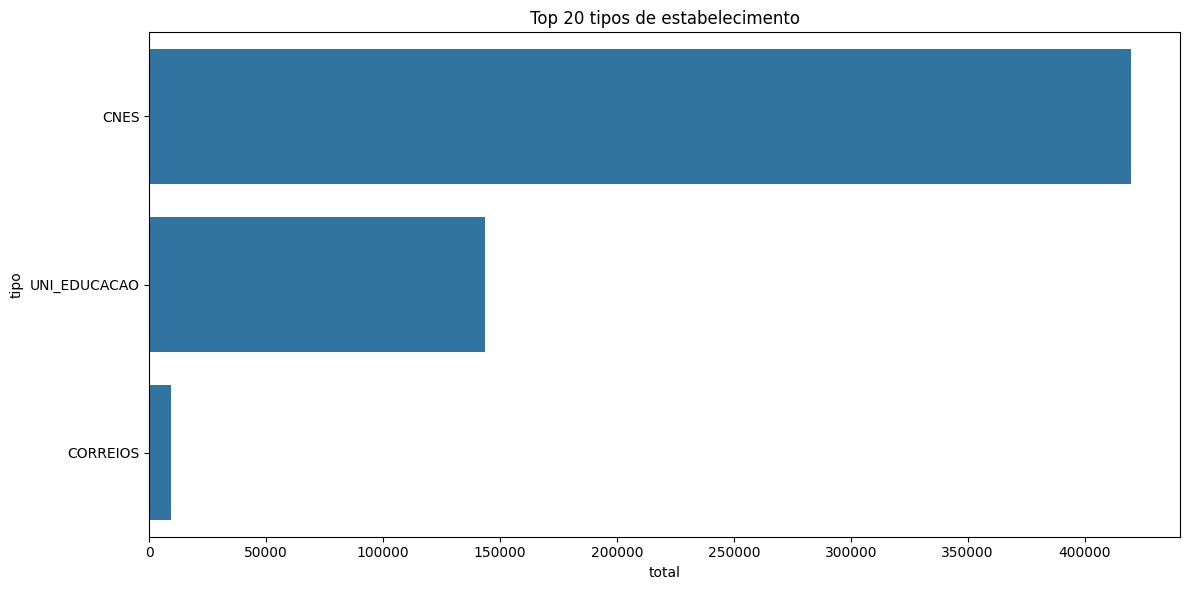

In [6]:
# Distribuição por tipo de estabelecimento
df_tipo = con.execute(f"""
    SELECT WEBSCRAPING_TIPO_ESTABELECIMENTO as tipo, COUNT(*) as total
    FROM read_parquet({SCRAPING})
    GROUP BY tipo
    ORDER BY total DESC
    LIMIT 20
""").df()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_tipo, x='total', y='tipo')
plt.title('Top 20 tipos de estabelecimento')
plt.tight_layout()
plt.savefig('../outputs/figures/scraping_por_tipo.png', dpi=150)
plt.show()

In [7]:
# Distribuição por UF
con.execute(f"""
    SELECT WEBSCRAPING_UF as uf, COUNT(*) as total
    FROM read_parquet({SCRAPING})
    GROUP BY uf
    ORDER BY total DESC
""").df()

,uf,total
0,35,130194
1,31,69525
2,33,44126
3,43,40332
4,41,40279
5,42,29395
6,29,29355
7,23,20973
8,26,18116
9,52,17687
